In [ ]:
"""
=============================================================================
01_data_preprocessing.py
Malaysia Tourism Carrying Capacity Early Warning System
Step 1: Data Preprocessing & Cleaning
=============================================================================
Reads raw data from:
  - Null_Datathon.xlsx  (environment + infrastructure metrics)
  - guest_accommodation.pdf  (accommodation distribution by state, from DOSM)
  - Hardcoded Prophet forecast data (state-level 2025-2028)
  - Hardcoded accommodation capacity & occupancy data (national AOR)

Outputs:
  - data/cleaned_environment.csv
  - data/cleaned_accommodation.csv
  - data/cleaned_demand_forecast.csv
  - data/destination_master.csv  (merged, Power BI-ready)
"""

import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = "data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================================
# SECTION 1: Parse Environment + Infrastructure Data (from Excel)
# ============================================================================
print("=" * 60)
print("SECTION 1: Environment + Infrastructure Data")
print("=" * 60)

# Raw data extracted from Null_Datathon.xlsx
env_data = [
    # Pulau Redang
    {"destination": "Pulau Redang", "admin_level": "District", "category": "Marine Ecology",
     "metric": "Coral cover", "year": 2025, "value_raw": "0.2589", "unit": "ratio",
     "source": "Reef Check Malaysia 2025"},
    {"destination": "Pulau Redang", "admin_level": "District", "category": "Capacity",
     "metric": "Visitor Demand", "year": 2025, "value_raw": "15.46 millions", "unit": "persons",
     "source": "DOSM Tourism 2025"},
    {"destination": "Pulau Redang", "admin_level": "State (Terengganu)", "category": "Water",
     "metric": "Non-domestic water consumption", "year": 2022, "value_raw": "173 MLD", "unit": "MLD",
     "source": "DOSM Water Catalogue"},
    {"destination": "Pulau Redang", "admin_level": "State (Terengganu)", "category": "Infrastructure",
     "metric": "Non-Revenue Water (NRW)", "year": 2025, "value_raw": "0.42", "unit": "ratio",
     "source": "SPAN Report 2025"},

    # Cameron Highlands
    {"destination": "Cameron Highlands", "admin_level": "District", "category": "Capacity",
     "metric": "District Population", "year": 2025, "value_raw": "44.8 thousand", "unit": "persons",
     "source": "DOSM Population Catalogue"},
    {"destination": "Cameron Highlands", "admin_level": "District", "category": "Hazard / Landslide",
     "metric": "Landslide Incident Count", "year": 2025, "value_raw": "2", "unit": "count",
     "source": "RTM / MDCameron"},
    {"destination": "Cameron Highlands", "admin_level": "State (Pahang)", "category": "Water",
     "metric": "Non-domestic water consumption", "year": 2022, "value_raw": "283 MLD", "unit": "MLD",
     "source": "DOSM Water Catalogue"},
    {"destination": "Cameron Highlands", "admin_level": "State (Pahang)", "category": "Infrastructure",
     "metric": "Non-Revenue Water (NRW)", "year": 2025, "value_raw": "0.485", "unit": "ratio",
     "source": "SPAN Report 2025"},

    # George Town
    {"destination": "George Town", "admin_level": "District (Timur Laut)", "category": "Capacity",
     "metric": "District Population", "year": 2025, "value_raw": "565.9 thousand", "unit": "persons",
     "source": "DOSM Population Catalogue"},
    {"destination": "George Town", "admin_level": "State (Penang)", "category": "Water",
     "metric": "Non-domestic water consumption", "year": 2022, "value_raw": "334 MLD", "unit": "MLD",
     "source": "DOSM Water Catalogue"},
    {"destination": "George Town", "admin_level": "State (Penang)", "category": "Infrastructure",
     "metric": "Non-Revenue Water (NRW)", "year": 2025, "value_raw": "0.284", "unit": "ratio",
     "source": "PBA Annual Report 2025"},
    {"destination": "George Town", "admin_level": "State (Penang)", "category": "Pollution",
     "metric": "River Basin Average WQI", "year": 2023, "value_raw": "74.125", "unit": "WQI (0-100)",
     "source": "DOE EQR 2023"},
    {"destination": "George Town", "admin_level": "Municipal (MBPP)", "category": "Waste",
     "metric": "Daily Solid Waste Generation", "year": None, "value_raw": "800 tonnes", "unit": "tonnes/day",
     "source": "Buletin Mutiara"},

    # Tunku Abdul Rahman Park
    {"destination": "Tunku Abdul Rahman Park", "admin_level": "Site / Park", "category": "Marine Ecology",
     "metric": "Coral cover", "year": 2025, "value_raw": "0.1313", "unit": "ratio",
     "source": "Reef Check Malaysia 2025"},
    {"destination": "Tunku Abdul Rahman Park", "admin_level": "District", "category": "Capacity",
     "metric": "Visitor Demand", "year": 2025, "value_raw": "546.38 thousand", "unit": "persons",
     "source": "Sabah Parks Dashboard"},
    {"destination": "Tunku Abdul Rahman Park", "admin_level": "State (Sabah)", "category": "Water",
     "metric": "Non-domestic water consumption", "year": 2022, "value_raw": "238 MLD", "unit": "MLD",
     "source": "DOSM Water Catalogue"},
    {"destination": "Tunku Abdul Rahman Park", "admin_level": "State (Sabah)", "category": "Infrastructure",
     "metric": "Non-Revenue Water (NRW)", "year": 2025, "value_raw": "0.596", "unit": "ratio",
     "source": "NST / Sabah NRW Report"},
]

df_env = pd.DataFrame(env_data)


def parse_value(raw, unit):
    """Clean and standardize raw values into numeric."""
    if pd.isna(raw):
        return np.nan
    s = str(raw).strip()
    # Remove unit suffixes
    for suffix in [" millions", " million", " thousand", " MLD", " tonnes", " WQI Index (0-100)"]:
        s = s.replace(suffix, "")
    s = s.strip()
    try:
        val = float(s)
    except ValueError:
        return np.nan

    # Scale based on original text
    raw_str = str(raw).lower()
    if "million" in raw_str:
        val = val * 1_000_000
    elif "thousand" in raw_str:
        val = val * 1_000
    return val


df_env["value_numeric"] = df_env.apply(lambda r: parse_value(r["value_raw"], r["unit"]), axis=1)

# Map destinations to states
dest_state_map = {
    "Pulau Redang": "Terengganu",
    "Cameron Highlands": "Pahang",
    "George Town": "Pulau Pinang",
    "Tunku Abdul Rahman Park": "Sabah",
}
df_env["state"] = df_env["destination"].map(dest_state_map)

print(f"  Loaded {len(df_env)} environment/infrastructure records")
print(f"  Destinations: {df_env['destination'].unique().tolist()}")
print(f"  Categories: {df_env['category'].unique().tolist()}")
df_env.to_csv(f"{OUTPUT_DIR}/cleaned_environment.csv", index=False)
print(f"  Saved → {OUTPUT_DIR}/cleaned_environment.csv")


# ============================================================================
# SECTION 2: Guest Accommodation Data (from PDF - Table 12 per state)
# ============================================================================
print("\n" + "=" * 60)
print("SECTION 2: Guest Accommodation Distribution")
print("=" * 60)

# Data extracted from guest_accommodation.pdf (DOSM Table 12 by state, 2024 %)
accom_data_2024 = {
    "Johor":            {"relatives_friends": 64.9, "hotel": 22.3, "chalet": 2.3, "apartment": 2.9, "homestay": 5.6, "rest_house": 2.0},
    "Kedah":            {"relatives_friends": 68.5, "hotel": 14.2, "chalet": 1.8, "apartment": 2.0, "homestay": 11.4, "rest_house": 2.1},
    "Kelantan":         {"relatives_friends": 73.1, "hotel": 10.7, "chalet": 2.1, "apartment": 1.1, "homestay": 8.0, "rest_house": 5.0},
    "Melaka":           {"relatives_friends": 45.5, "hotel": 28.4, "chalet": 4.5, "apartment": 7.7, "homestay": 12.2, "rest_house": 1.7},
    "Negeri Sembilan":  {"relatives_friends": 63.4, "hotel": 23.2, "chalet": 1.9, "apartment": 4.6, "homestay": 4.3, "rest_house": 2.6},
    "Pahang":           {"relatives_friends": 51.2, "hotel": 32.1, "chalet": 4.8, "apartment": 3.7, "homestay": 6.7, "rest_house": 1.5},
    "Pulau Pinang":     {"relatives_friends": 50.7, "hotel": 31.7, "chalet": 0.7, "apartment": 5.7, "homestay": 10.1, "rest_house": 1.1},
    "Perak":            {"relatives_friends": 69.0, "hotel": 16.2, "chalet": 3.3, "apartment": 2.4, "homestay": 7.9, "rest_house": 1.2},
    "Perlis":           {"relatives_friends": 58.4, "hotel": 16.9, "chalet": 0.0, "apartment": 2.7, "homestay": 19.7, "rest_house": 2.3},
    "Selangor":         {"relatives_friends": 68.7, "hotel": 13.8, "chalet": 0.3, "apartment": 4.9, "homestay": 8.6, "rest_house": 3.7},
    "Terengganu":       {"relatives_friends": 60.6, "hotel": 20.4, "chalet": 4.2, "apartment": 1.2, "homestay": 9.8, "rest_house": 3.8},
    "Sabah":            {"relatives_friends": 54.6, "hotel": 19.1, "chalet": 1.1, "apartment": 2.3, "homestay": 17.2, "rest_house": 5.7},
    "Sarawak":          {"relatives_friends": 66.5, "hotel": 20.2, "chalet": 1.8, "apartment": 3.7, "homestay": 3.3, "rest_house": 4.5},
    "W.P. Kuala Lumpur":{"relatives_friends": 48.3, "hotel": 29.1, "chalet": 3.0, "apartment": 9.2, "homestay": 8.0, "rest_house": 2.4},
    "W.P. Labuan":      {"relatives_friends": 38.9, "hotel": 45.2, "chalet": 4.0, "apartment": 2.3, "homestay": 6.1, "rest_house": 3.5},
    "W.P. Putrajaya":   {"relatives_friends": 46.1, "hotel": 26.0, "chalet": 0.0, "apartment": 8.1, "homestay": 12.6, "rest_house": 7.2},
}

rows = []
for state, types in accom_data_2024.items():
    for accom_type, pct in types.items():
        rows.append({"state": state, "year": 2024, "accommodation_type": accom_type, "percentage": pct})

df_accom = pd.DataFrame(rows)

# Compute formal accommodation ratio (hotel + chalet + apartment = "formal")
formal_accom = df_accom[df_accom["accommodation_type"].isin(["hotel", "chalet", "apartment"])]\
    .groupby("state")["percentage"].sum().reset_index()
formal_accom.columns = ["state", "formal_accommodation_pct"]

# Informal = relatives/friends + homestay + rest house
informal_accom = df_accom[df_accom["accommodation_type"].isin(["relatives_friends", "homestay", "rest_house"])]\
    .groupby("state")["percentage"].sum().reset_index()
informal_accom.columns = ["state", "informal_accommodation_pct"]

df_accom_summary = formal_accom.merge(informal_accom, on="state")
df_accom_summary["hotel_pct"] = df_accom_summary["state"].map(
    {s: d["hotel"] for s, d in accom_data_2024.items()}
)

print(f"  Loaded accommodation data for {len(accom_data_2024)} states")
print(f"  Key focus states:")
for dest, state in dest_state_map.items():
    row = df_accom_summary[df_accom_summary["state"] == state]
    if not row.empty:
        r = row.iloc[0]
        print(f"    {state} ({dest}): Hotel {r['hotel_pct']:.1f}%, "
              f"Formal {r['formal_accommodation_pct']:.1f}%, "
              f"Informal {r['informal_accommodation_pct']:.1f}%")

df_accom.to_csv(f"{OUTPUT_DIR}/cleaned_accommodation.csv", index=False)
df_accom_summary.to_csv(f"{OUTPUT_DIR}/accommodation_summary.csv", index=False)
print(f"  Saved → {OUTPUT_DIR}/cleaned_accommodation.csv")
print(f"  Saved → {OUTPUT_DIR}/accommodation_summary.csv")


# ============================================================================
# SECTION 3: Demand Forecast Data (Prophet outputs - state level 2025-2028)
# ============================================================================
print("\n" + "=" * 60)
print("SECTION 3: Demand Forecast Data (Prophet Predictions)")
print("=" * 60)

# Real Prophet forecast outputs (from Preditation_of_every_state_in_2026_.txt)
# Format: state -> {year: predicted_domestic_visitors_thousands}
# 2024 = DOSM actuals / last known baseline
# 2025 = Prophet yhat at 2025-12-31 (end-of-year prediction)
# 2026-2028 = Prophet yhat for each year-end date
# NOTE: Perlis was not included in the Prophet run; 2025-2028 kept as
#       trend-based estimates anchored to the 2024 baseline.
forecast_data = {
    # 2024 actuals kept; 2025-2028 from Prophet (yhat, rounded to nearest integer)
    "Selangor":         {2024: 45000, 2025: 37325, 2026: 39774, 2027: 42113, 2028: 39093},
    "Johor":            {2024: 29481, 2025: 19669, 2026: 21164, 2027: 22580, 2028: 22160},
    "Kedah":            {2024: 11200, 2025: 16854, 2026: 17918, 2027: 18921, 2028: 17082},
    "Kelantan":         {2024: 6800,  2025: 11273, 2026: 12005, 2027: 12708, 2028: 11685},
    "Melaka":           {2024: 10200, 2025: 21685, 2026: 23544, 2027: 25334, 2028: 25264},
    "Negeri Sembilan":  {2024: 8500,  2025: 19693, 2026: 21123, 2027: 22479, 2028: 22858},
    "Pahang":           {2024: 22500, 2025: 22222, 2026: 23754, 2027: 25217, 2028: 24286},
    "Pulau Pinang":     {2024: 12800, 2025: 17616, 2026: 18745, 2027: 19825, 2028: 18798},
    "Perak":            {2024: 14500, 2025: 25499, 2026: 27603, 2027: 29633, 2028: 26862},
    "Terengganu":       {2024: 15460, 2025: 15045, 2026: 15854, 2027: 16612, 2028: 15887},
    "Sabah":            {2024: 8900,  2025: 21367, 2026: 22631, 2027: 23835, 2028: 21820},
    "Sarawak":          {2024: 7200,  2025: 19877, 2026: 20474, 2027: 20985, 2028: 21981},
    "W.P. Kuala Lumpur":{2024: 35000, 2025: 29712, 2026: 31515, 2027: 33227, 2028: 35971},
    "W.P. Labuan":      {2024: 500,   2025: 364,   2026: 361,   2027: 356,   2028: 409},
    "W.P. Putrajaya":   {2024: 2200,  2025: 2633,  2026: 2829,  2027: 3017,  2028: 3255},
    # Perlis: Prophet model not run; trend-based estimate retained as fallback
    "Perlis":           {2024: 1800,  2025: 1900,  2026: 2100,  2027: 2300,  2028: 2400},
}

rows = []
for state, years in forecast_data.items():
    for year, visitors_k in years.items():
        rows.append({
            "state": state,
            "year": year,
            "predicted_visitors_thousands": visitors_k,
            "predicted_visitors": visitors_k * 1000,
        })

df_forecast = pd.DataFrame(rows)

# Compute YoY growth rates
df_forecast = df_forecast.sort_values(["state", "year"])
df_forecast["yoy_growth_pct"] = df_forecast.groupby("state")["predicted_visitors"].pct_change() * 100

# Flag high-growth states (>10% YoY)
df_forecast["high_growth_flag"] = df_forecast["yoy_growth_pct"] > 10

print(f"  Loaded forecasts for {df_forecast['state'].nunique()} states, "
      f"{df_forecast['year'].nunique()} years")
print(f"  Total predicted visitors 2026: "
      f"{df_forecast[df_forecast['year']==2026]['predicted_visitors'].sum()/1e6:.1f}M")

# Show high-growth states for 2026
hg_2026 = df_forecast[(df_forecast["year"] == 2026) & (df_forecast["high_growth_flag"])]
if not hg_2026.empty:
    print(f"  High-growth states (>10% YoY) for 2026:")
    for _, r in hg_2026.iterrows():
        print(f"    {r['state']}: {r['yoy_growth_pct']:.1f}%")

df_forecast.to_csv(f"{OUTPUT_DIR}/cleaned_demand_forecast.csv", index=False)
print(f"  Saved → {OUTPUT_DIR}/cleaned_demand_forecast.csv")


# ============================================================================
# SECTION 4: Hotel Capacity Data (rooms, occupancy)
# ============================================================================
print("\n" + "=" * 60)
print("SECTION 4: Hotel Capacity & Occupancy Data")
print("=" * 60)

# Hotel rooms by state (from DOSM state tourism reports, Table 14/15)
# Hotel occupancy from national AOR (Average Occupancy Rate)
hotel_data = {
    "Johor":            {"hotel_rooms": 31971, "aor_2024": 58.2},
    "Kedah":            {"hotel_rooms": 18500, "aor_2024": 62.5},
    "Kelantan":         {"hotel_rooms": 5200,  "aor_2024": 48.3},
    "Melaka":           {"hotel_rooms": 16800, "aor_2024": 55.7},
    "Negeri Sembilan":  {"hotel_rooms": 6200,  "aor_2024": 50.1},
    "Pahang":           {"hotel_rooms": 22400, "aor_2024": 54.8},
    "Pulau Pinang":     {"hotel_rooms": 21500, "aor_2024": 65.3},
    "Perak":            {"hotel_rooms": 14300, "aor_2024": 52.4},
    "Perlis":           {"hotel_rooms": 1800,  "aor_2024": 45.6},
    "Selangor":         {"hotel_rooms": 38000, "aor_2024": 61.2},
    "Terengganu":       {"hotel_rooms": 9800,  "aor_2024": 56.9},
    "Sabah":            {"hotel_rooms": 18700, "aor_2024": 57.4},
    "Sarawak":          {"hotel_rooms": 16200, "aor_2024": 53.8},
    "W.P. Kuala Lumpur":{"hotel_rooms": 52000, "aor_2024": 68.7},
    "W.P. Labuan":      {"hotel_rooms": 2100,  "aor_2024": 42.1},
    "W.P. Putrajaya":   {"hotel_rooms": 3500,  "aor_2024": 47.5},
}

df_hotel = pd.DataFrame([
    {"state": s, **d} for s, d in hotel_data.items()
])

# Compute room-nights capacity per year (rooms × 365 × max_occupancy_target)
df_hotel["annual_room_nights_capacity"] = df_hotel["hotel_rooms"] * 365
df_hotel["annual_room_nights_used_2024"] = (
    df_hotel["hotel_rooms"] * 365 * df_hotel["aor_2024"] / 100
)
# Remaining capacity headroom
df_hotel["occupancy_headroom_pct"] = 85.0 - df_hotel["aor_2024"]  # 85% = industry stress threshold

print(f"  Loaded hotel data for {len(df_hotel)} states")
print(f"  Total rooms nationally: {df_hotel['hotel_rooms'].sum():,}")

for dest, state in dest_state_map.items():
    row = df_hotel[df_hotel["state"] == state]
    if not row.empty:
        r = row.iloc[0]
        print(f"    {state}: {r['hotel_rooms']:,} rooms, AOR {r['aor_2024']:.1f}%, "
              f"headroom {r['occupancy_headroom_pct']:.1f}pp")

df_hotel.to_csv(f"{OUTPUT_DIR}/cleaned_hotel_capacity.csv", index=False)
print(f"  Saved → {OUTPUT_DIR}/cleaned_hotel_capacity.csv")


# ============================================================================
# SECTION 5: Build Destination Master Table
# ============================================================================
print("\n" + "=" * 60)
print("SECTION 5: Destination Master Table")
print("=" * 60)

destinations = []
for dest, state in dest_state_map.items():
    record = {"destination": dest, "state": state}

    # Environment metrics (pivot from env data)
    dest_env = df_env[df_env["destination"] == dest]
    for _, row in dest_env.iterrows():
        key = f"{row['category']}_{row['metric']}".replace(" ", "_").replace("/", "_").lower()
        record[key] = row["value_numeric"]
        record[f"{key}_year"] = row["year"]

    # Accommodation
    accom_row = df_accom_summary[df_accom_summary["state"] == state]
    if not accom_row.empty:
        record["hotel_pct"] = accom_row.iloc[0]["hotel_pct"]
        record["formal_accommodation_pct"] = accom_row.iloc[0]["formal_accommodation_pct"]

    # Hotel capacity
    hotel_row = df_hotel[df_hotel["state"] == state]
    if not hotel_row.empty:
        record["hotel_rooms"] = hotel_row.iloc[0]["hotel_rooms"]
        record["aor_2024"] = hotel_row.iloc[0]["aor_2024"]
        record["occupancy_headroom_pct"] = hotel_row.iloc[0]["occupancy_headroom_pct"]

    # Demand forecast 2026
    fc_row = df_forecast[(df_forecast["state"] == state) & (df_forecast["year"] == 2026)]
    if not fc_row.empty:
        record["predicted_visitors_2026"] = fc_row.iloc[0]["predicted_visitors"]
        record["yoy_growth_2026_pct"] = fc_row.iloc[0]["yoy_growth_pct"]

    destinations.append(record)

df_master = pd.DataFrame(destinations)
df_master.to_csv(f"{OUTPUT_DIR}/destination_master.csv", index=False)
print(f"  Built master table: {df_master.shape[0]} destinations × {df_master.shape[1]} columns")
print(f"  Columns: {df_master.columns.tolist()}")
print(f"\n  Saved → {OUTPUT_DIR}/destination_master.csv")

print("\n" + "=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)

SECTION 1: Environment + Infrastructure Data
  Loaded 17 environment/infrastructure records
  Destinations: ['Pulau Redang', 'Cameron Highlands', 'George Town', 'Tunku Abdul Rahman Park']
  Categories: ['Marine Ecology', 'Capacity', 'Water', 'Infrastructure', 'Hazard / Landslide', 'Pollution', 'Waste']
  Saved → data/cleaned_environment.csv

SECTION 2: Guest Accommodation Distribution
  Loaded accommodation data for 16 states
  Key focus states:
    Terengganu (Pulau Redang): Hotel 20.4%, Formal 25.8%, Informal 74.2%
    Pahang (Cameron Highlands): Hotel 32.1%, Formal 40.6%, Informal 59.4%
    Pulau Pinang (George Town): Hotel 31.7%, Formal 38.1%, Informal 61.9%
    Sabah (Tunku Abdul Rahman Park): Hotel 19.1%, Formal 22.5%, Informal 77.5%
  Saved → data/cleaned_accommodation.csv
  Saved → data/accommodation_summary.csv

SECTION 3: Demand Forecast Data (Prophet Predictions)
  Loaded forecasts for 16 states, 5 years
  Total predicted visitors 2026: 301.4M
  High-growth states (>10% YoY)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
"""
=============================================================================
02_capacity_index.py
Malaysia Tourism Carrying Capacity Early Warning System
Step 2: Capacity Index Construction (AHP + Entropy Weight Method)
=============================================================================
Computes the Tourism Carrying Capacity Index (TCCI) for each destination
using two weighting approaches:
  1. AHP (Analytic Hierarchy Process) - literature-based weights
  2. Entropy Weight Method - data-driven weights
Then validates consistency between them.

Classification:
  Green  (Safe):    Index < 0.7
  Yellow (Warning): 0.7 <= Index < 1.0
  Red    (Critical):Index >= 1.0

Outputs:
  - data/capacity_index_results.csv
  - data/ahp_weights.csv
  - data/entropy_weights.csv
  - data/classification_results.csv
"""

import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = "data"

# ============================================================================
# SECTION 1: Define Indicators and Normalize
# ============================================================================
print("=" * 60)
print("SECTION 1: Indicator System Design")
print("=" * 60)

# Load preprocessed data
df_env = pd.read_csv(f"{DATA_DIR}/cleaned_environment.csv")
df_hotel = pd.read_csv(f"{DATA_DIR}/cleaned_hotel_capacity.csv")
df_accom = pd.read_csv(f"{DATA_DIR}/accommodation_summary.csv")
df_forecast = pd.read_csv(f"{DATA_DIR}/cleaned_demand_forecast.csv")

dest_state_map = {
    "Pulau Redang": "Terengganu",
    "Cameron Highlands": "Pahang",
    "George Town": "Pulau Pinang",
    "Tunku Abdul Rahman Park": "Sabah",
}

# Build indicator matrix: rows = destinations, columns = indicators
# Each indicator is normalized to [0, 1] where 1 = worst (highest pressure)

indicators = {}

for dest, state in dest_state_map.items():
    row = {}
    dest_env = df_env[df_env["destination"] == dest]

    # --- I1: Water Stress (NRW ratio) ---
    # Higher NRW = more water loss = worse infrastructure
    nrw = dest_env[dest_env["metric"] == "Non-Revenue Water (NRW)"]["value_numeric"]
    row["I1_NRW"] = nrw.values[0] if len(nrw) > 0 else np.nan

    # --- I2: Coral / Ecological Health (inverted: lower coral = worse) ---
    coral = dest_env[dest_env["metric"] == "Coral cover"]["value_numeric"]
    if len(coral) > 0:
        # Invert: 1 - coral_cover (so low coral → high pressure)
        row["I2_Ecological_Pressure"] = 1 - coral.values[0]
    else:
        # For non-marine destinations, use a proxy
        # Cameron Highlands: landslide count normalized
        landslide = dest_env[dest_env["metric"] == "Landslide Incident Count"]["value_numeric"]
        if len(landslide) > 0:
            # Normalize: 2 incidents in a year is moderate risk; 5+ would be severe
            row["I2_Ecological_Pressure"] = min(landslide.values[0] / 5.0, 1.0)
        else:
            # George Town: use WQI (inverted: lower WQI = worse water quality)
            wqi = dest_env[dest_env["metric"] == "River Basin Average WQI"]["value_numeric"]
            if len(wqi) > 0:
                # WQI 0-100, invert and normalize
                row["I2_Ecological_Pressure"] = 1 - (wqi.values[0] / 100.0)
            else:
                row["I2_Ecological_Pressure"] = 0.5  # neutral default

    # --- I3: Accommodation Pressure ---
    # High hotel occupancy + low formal accommodation share = more pressure
    hotel_row = df_hotel[df_hotel["state"] == state]
    if not hotel_row.empty:
        aor = hotel_row.iloc[0]["aor_2024"]
        # Normalize AOR: 40% = low pressure (0.0), 85% = full pressure (1.0)
        row["I3_Accommodation_Pressure"] = np.clip((aor - 40) / (85 - 40), 0, 1)
    else:
        row["I3_Accommodation_Pressure"] = 0.5

    # --- I4: Demand Growth Pressure ---
    # Higher YoY growth = more pressure on capacity
    fc = df_forecast[(df_forecast["state"] == state) & (df_forecast["year"] == 2026)]
    if not fc.empty:
        growth = fc.iloc[0]["yoy_growth_pct"]
        # Normalize: 0% = no pressure (0.0), 15% = high pressure (1.0)
        row["I4_Demand_Growth_Pressure"] = np.clip(growth / 15.0, 0, 1) if not pd.isna(growth) else 0.5
    else:
        row["I4_Demand_Growth_Pressure"] = 0.5

    # --- I5: Water Consumption Stress ---
    water = dest_env[dest_env["metric"] == "Non-domestic water consumption"]["value_numeric"]
    if len(water) > 0:
        # Higher consumption relative to state capacity = worse
        # Normalize: 100 MLD = low (0.0), 400 MLD = high (1.0)
        row["I5_Water_Consumption"] = np.clip((water.values[0] - 100) / (400 - 100), 0, 1)
    else:
        row["I5_Water_Consumption"] = 0.5

    indicators[dest] = row

df_indicators = pd.DataFrame(indicators).T
df_indicators.index.name = "destination"
df_indicators = df_indicators.reset_index()

print("Indicator Matrix (raw normalized 0-1, where 1 = worst):")
print(df_indicators.to_string(index=False, float_format="{:.4f}".format))
print()

indicator_cols = [c for c in df_indicators.columns if c.startswith("I")]
print(f"  Indicators: {indicator_cols}")


# ============================================================================
# SECTION 2: AHP Weighting (Literature-Based)
# ============================================================================
print("\n" + "=" * 60)
print("SECTION 2: AHP Weighting")
print("=" * 60)

# Reference: Perhentian Island carrying capacity study
# Biophysical environment: 0.291, Planning control: 0.250, Tourism facilities: 0.229
# Adapted for our 5-indicator system:

# Pairwise comparison matrix (Saaty scale 1-9)
# Order: I1_NRW, I2_Ecological, I3_Accommodation, I4_Demand, I5_Water
ahp_matrix = np.array([
    [1,   1/3, 1/2, 2,   1],     # I1: NRW
    [3,   1,   2,   3,   2],     # I2: Ecological (most important for marine/eco sites)
    [2,   1/2, 1,   2,   1],     # I3: Accommodation
    [1/2, 1/3, 1/2, 1,   1/2],  # I4: Demand Growth
    [1,   1/2, 1,   2,   1],     # I5: Water Consumption
])

# Compute AHP weights via geometric mean method
def ahp_weights(matrix):
    """Compute AHP priority weights using geometric mean method."""
    n = matrix.shape[0]
    # Geometric mean of each row
    geo_means = np.prod(matrix, axis=1) ** (1/n)
    # Normalize
    weights = geo_means / geo_means.sum()

    # Consistency check
    # λ_max approximation
    weighted_sum = matrix @ weights
    lambda_max = np.mean(weighted_sum / weights)
    CI = (lambda_max - n) / (n - 1)
    # Random Index for n=5
    RI = {1: 0, 2: 0, 3: 0.58, 4: 0.9, 5: 1.12, 6: 1.24, 7: 1.32}
    CR = CI / RI[n]

    return weights, lambda_max, CI, CR

w_ahp, lmax, ci, cr = ahp_weights(ahp_matrix)

print("AHP Pairwise Comparison Matrix:")
labels = ["I1_NRW", "I2_Ecological", "I3_Accommodation", "I4_Demand", "I5_Water"]
for i, label in enumerate(labels):
    row_str = "  ".join(f"{ahp_matrix[i,j]:.2f}" for j in range(len(labels)))
    print(f"  {label:20s}: {row_str}")

print(f"\nAHP Weights:")
for label, w in zip(labels, w_ahp):
    print(f"  {label:20s}: {w:.4f}")

print(f"\nConsistency Check:")
print(f"  λ_max = {lmax:.4f}")
print(f"  CI    = {ci:.4f}")
print(f"  CR    = {cr:.4f} {'✓ PASS (< 0.10)' if cr < 0.10 else '✗ FAIL (≥ 0.10)'}")

df_ahp_weights = pd.DataFrame({"indicator": labels, "ahp_weight": w_ahp})
df_ahp_weights.to_csv(f"{DATA_DIR}/ahp_weights.csv", index=False)


# ============================================================================
# SECTION 3: Entropy Weight Method (Data-Driven)
# ============================================================================
print("\n" + "=" * 60)
print("SECTION 3: Entropy Weight Method")
print("=" * 60)

def entropy_weights(data_matrix):
    """
    Compute weights using the Entropy Weight Method.
    data_matrix: numpy array (n_samples x n_indicators), all values in [0,1]
    """
    n, m = data_matrix.shape

    # Avoid log(0): add small epsilon
    eps = 1e-10

    # Normalize columns to proportions (each column sums to 1)
    col_sums = data_matrix.sum(axis=0)
    col_sums[col_sums == 0] = eps
    P = data_matrix / col_sums

    # Compute entropy for each indicator
    E = np.zeros(m)
    k = 1.0 / np.log(n)  # normalization constant
    for j in range(m):
        pj = P[:, j]
        pj = pj[pj > eps]  # only non-zero
        E[j] = -k * np.sum(pj * np.log(pj + eps))

    # Compute divergence coefficient
    D = 1 - E

    # Normalize to get weights
    w = D / D.sum()

    return w, E, D


# Extract indicator values as matrix
indicator_matrix = df_indicators[indicator_cols].values

w_entropy, E_vals, D_vals = entropy_weights(indicator_matrix)

print("Entropy Analysis:")
print(f"  {'Indicator':20s}  {'Entropy':>8s}  {'Divergence':>10s}  {'Weight':>8s}")
for i, label in enumerate(labels):
    print(f"  {label:20s}  {E_vals[i]:8.4f}  {D_vals[i]:10.4f}  {w_entropy[i]:8.4f}")

df_entropy_weights = pd.DataFrame({
    "indicator": labels,
    "entropy": E_vals,
    "divergence": D_vals,
    "entropy_weight": w_entropy
})
df_entropy_weights.to_csv(f"{DATA_DIR}/entropy_weights.csv", index=False)


# ============================================================================
# SECTION 4: Compute Capacity Index
# ============================================================================
print("\n" + "=" * 60)
print("SECTION 4: Capacity Index Computation")
print("=" * 60)

# Compute weighted index using both methods
df_results = df_indicators.copy()

# AHP-weighted index
df_results["TCCI_AHP"] = (indicator_matrix * w_ahp).sum(axis=1)

# Entropy-weighted index
df_results["TCCI_Entropy"] = (indicator_matrix * w_entropy).sum(axis=1)

# Combined (average of both for robustness)
df_results["TCCI_Combined"] = (df_results["TCCI_AHP"] + df_results["TCCI_Entropy"]) / 2

# Scale to interpretable range (multiply by a factor so thresholds align)
# Current values are 0-1, we want < 0.7 = green, 0.7-1.0 = yellow, >1.0 = red
# Scale factor to spread the distribution
SCALE_FACTOR = 1.5  # adjustable based on calibration

for col in ["TCCI_AHP", "TCCI_Entropy", "TCCI_Combined"]:
    df_results[f"{col}_scaled"] = df_results[col] * SCALE_FACTOR

print("Capacity Index Results:")
print(f"  {'Destination':30s}  {'AHP':>6s}  {'Entropy':>8s}  {'Combined':>9s}  "
      f"{'Scaled_AHP':>10s}  {'Scaled_Ent':>10s}  {'Scaled_Comb':>11s}")
for _, r in df_results.iterrows():
    print(f"  {r['destination']:30s}  {r['TCCI_AHP']:6.4f}  {r['TCCI_Entropy']:8.4f}  "
          f"{r['TCCI_Combined']:9.4f}  {r['TCCI_AHP_scaled']:10.4f}  "
          f"{r['TCCI_Entropy_scaled']:10.4f}  {r['TCCI_Combined_scaled']:11.4f}")


# ============================================================================
# SECTION 5: Consistency Validation
# ============================================================================
print("\n" + "=" * 60)
print("SECTION 5: Consistency Validation (AHP vs Entropy)")
print("=" * 60)

# Spearman rank correlation between AHP and Entropy indices
corr, pval = spearmanr(df_results["TCCI_AHP"], df_results["TCCI_Entropy"])
print(f"  Spearman correlation: {corr:.4f} (p = {pval:.4f})")
print(f"  Interpretation: {'Strong consistency ✓' if abs(corr) > 0.8 else 'Moderate consistency' if abs(corr) > 0.6 else 'Weak consistency ✗'}")

# Weight comparison
print(f"\n  Weight Comparison:")
print(f"  {'Indicator':20s}  {'AHP':>8s}  {'Entropy':>8s}  {'Diff':>8s}")
for i, label in enumerate(labels):
    diff = abs(w_ahp[i] - w_entropy[i])
    print(f"  {label:20s}  {w_ahp[i]:8.4f}  {w_entropy[i]:8.4f}  {diff:8.4f}")


# ============================================================================
# SECTION 6: Warning Classification
# ============================================================================
print("\n" + "=" * 60)
print("SECTION 6: Warning Classification (Green / Yellow / Red)")
print("=" * 60)

# Thresholds (based on scaled combined index)
def classify_warning(score):
    if score < 0.70:
        return "Green (Safe)"
    elif score < 1.00:
        return "Yellow (Warning)"
    else:
        return "Red (Critical)"

def classify_color(score):
    if score < 0.70:
        return "green"
    elif score < 1.00:
        return "yellow"
    else:
        return "red"

df_results["warning_level"] = df_results["TCCI_Combined_scaled"].apply(classify_warning)
df_results["warning_color"] = df_results["TCCI_Combined_scaled"].apply(classify_color)

# Add state mapping
df_results["state"] = df_results["destination"].map(dest_state_map)

print("Classification Results (using scaled combined TCCI):")
print(f"  {'Destination':30s}  {'Score':>6s}  {'Level':20s}")
for _, r in df_results.iterrows():
    emoji = {"green": "🟢", "yellow": "🟡", "red": "🔴"}[r["warning_color"]]
    print(f"  {emoji} {r['destination']:28s}  {r['TCCI_Combined_scaled']:6.3f}  {r['warning_level']}")

df_results.to_csv(f"{DATA_DIR}/capacity_index_results.csv", index=False)
print(f"\n  Saved → {DATA_DIR}/capacity_index_results.csv")


# ============================================================================
# SECTION 7: K-Means Validation of Thresholds
# ============================================================================
print("\n" + "=" * 60)
print("SECTION 7: K-Means Clustering Validation")
print("=" * 60)

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Cluster on scaled combined TCCI
scores = df_results["TCCI_Combined_scaled"].values.reshape(-1, 1)

# K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scores)

# Map clusters to ordered severity (lowest centroid = green)
centroids = kmeans.cluster_centers_.flatten()
cluster_order = np.argsort(centroids)
cluster_map = {cluster_order[i]: i for i in range(3)}
ordered_labels = [cluster_map[c] for c in cluster_labels]
cluster_names = {0: "Green (Safe)", 1: "Yellow (Warning)", 2: "Red (Critical)"}

df_results["kmeans_cluster"] = ordered_labels
df_results["kmeans_label"] = [cluster_names[c] for c in ordered_labels]

# Compare rule-based vs K-Means classification
rule_labels_num = df_results["warning_color"].map({"green": 0, "yellow": 1, "red": 2}).values
agreement = (np.array(ordered_labels) == rule_labels_num).sum() / len(rule_labels_num) * 100

print(f"  K-Means centroids: {sorted(centroids)}")
print(f"  Rule-based vs K-Means agreement: {agreement:.0f}%")
print(f"\n  {'Destination':30s}  {'Rule-Based':20s}  {'K-Means':20s}  {'Match':>5s}")
for _, r in df_results.iterrows():
    match = "✓" if r["warning_level"] == r["kmeans_label"] else "✗"
    print(f"  {r['destination']:30s}  {r['warning_level']:20s}  {r['kmeans_label']:20s}  {match:>5s}")

df_results.to_csv(f"{DATA_DIR}/classification_results.csv", index=False)
print(f"\n  Saved → {DATA_DIR}/classification_results.csv")

print("\n" + "=" * 60)
print("CAPACITY INDEX COMPUTATION COMPLETE")
print("=" * 60)

SECTION 1: Indicator System Design
Indicator Matrix (raw normalized 0-1, where 1 = worst):
            destination  I1_NRW  I2_Ecological_Pressure  I3_Accommodation_Pressure  I4_Demand_Growth_Pressure  I5_Water_Consumption
           Pulau Redang  0.4200                  0.7411                     0.3756                     0.3585                0.2433
      Cameron Highlands  0.4850                  0.4000                     0.3289                     0.4596                0.6100
            George Town  0.2840                  0.2588                     0.5622                     0.4273                0.7800
Tunku Abdul Rahman Park  0.5960                  0.8687                     0.3867                     0.3944                0.4600

  Indicators: ['I1_NRW', 'I2_Ecological_Pressure', 'I3_Accommodation_Pressure', 'I4_Demand_Growth_Pressure', 'I5_Water_Consumption']

SECTION 2: AHP Weighting
AHP Pairwise Comparison Matrix:
  I1_NRW              : 1.00  0.33  0.50  2.00  1.00
  I2

In [ ]:
"""
=============================================================================
03_scenario_simulation.py
Malaysia Tourism Carrying Capacity Early Warning System
Step 3: What-If Scenario Simulation & Power BI Export
=============================================================================
Simulates policy intervention scenarios:
  - Baseline (do nothing)
  - Limit visitors by X%
  - Infrastructure investment
  - Combined measures

Outputs Power BI-ready tables:
  - outputs/powerbi_state_forecast.csv          (Layer 1: state-level scan)
  - outputs/powerbi_destination_index.csv       (Layer 2: destination focus)
  - outputs/powerbi_scenario_comparison.csv     (Layer 3: what-if results)
  - outputs/powerbi_indicator_detail.csv        (indicator breakdown)
  - outputs/powerbi_accommodation_by_state.csv  (accommodation mix)
  - outputs/powerbi_recommendations.csv         (action recommendations)
"""

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = "data"
OUTPUT_DIR = "outputs"
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load results from previous steps
df_results = pd.read_csv(f"{DATA_DIR}/classification_results.csv")
df_forecast = pd.read_csv(f"{DATA_DIR}/cleaned_demand_forecast.csv")
df_hotel = pd.read_csv(f"{DATA_DIR}/cleaned_hotel_capacity.csv")
df_accom = pd.read_csv(f"{DATA_DIR}/cleaned_accommodation.csv")
df_accom_summary = pd.read_csv(f"{DATA_DIR}/accommodation_summary.csv")
df_env = pd.read_csv(f"{DATA_DIR}/cleaned_environment.csv")
df_ahp = pd.read_csv(f"{DATA_DIR}/ahp_weights.csv")
df_entropy = pd.read_csv(f"{DATA_DIR}/entropy_weights.csv")

dest_state_map = {
    "Pulau Redang": "Terengganu",
    "Cameron Highlands": "Pahang",
    "George Town": "Pulau Pinang",
    "Tunku Abdul Rahman Park": "Sabah",
}

# ============================================================================
# SECTION 1: What-If Scenario Simulation
# ============================================================================
print("=" * 60)
print("SECTION 1: What-If Scenario Simulation")
print("=" * 60)

SCALE_FACTOR = 1.5  # same as in model training

# Load AHP weights
ahp_weights = df_ahp["ahp_weight"].values
indicator_cols = [c for c in df_results.columns if c.startswith("I")]

scenarios = []

for _, dest_row in df_results.iterrows():
    dest = dest_row["destination"]
    state = dest_row["state"]
    base_indicators = dest_row[indicator_cols].values.astype(float)
    base_score = dest_row["TCCI_Combined_scaled"]

    # Get 2026 forecast for revenue impact estimation
    fc = df_forecast[(df_forecast["state"] == state) & (df_forecast["year"] == 2026)]
    visitors_2026 = fc.iloc[0]["predicted_visitors"] if not fc.empty else 0
    # Estimate revenue per visitor (simplified: RM 2,500 avg per trip)
    revenue_per_visitor = 2500
    base_revenue = visitors_2026 * revenue_per_visitor

    # --- Scenario 1: Baseline (Do Nothing) ---
    scenarios.append({
        "destination": dest, "state": state,
        "scenario": "Baseline (Do Nothing)",
        "visitor_reduction_pct": 0,
        "tcci_score": base_score,
        "estimated_visitors": visitors_2026,
        "estimated_revenue_rm_millions": base_revenue / 1e6,
        "warning_level": dest_row["warning_level"],
    })

    # --- Scenario 2: Limit visitors by 20% ---
    reduced_visitors = visitors_2026 * 0.80
    # Reducing visitors lowers demand growth pressure (I4) and accommodation pressure (I3)
    mod_indicators = base_indicators.copy()
    mod_indicators[3] *= 0.75  # I4: demand growth pressure drops
    mod_indicators[2] *= 0.85  # I3: accommodation pressure eases
    mod_score = (mod_indicators * ahp_weights).sum() * SCALE_FACTOR

    def classify(s):
        if s < 0.70: return "Green (Safe)"
        elif s < 1.00: return "Yellow (Warning)"
        else: return "Red (Critical)"

    scenarios.append({
        "destination": dest, "state": state,
        "scenario": "Limit Visitors -20%",
        "visitor_reduction_pct": 20,
        "tcci_score": mod_score,
        "estimated_visitors": reduced_visitors,
        "estimated_revenue_rm_millions": reduced_visitors * revenue_per_visitor / 1e6,
        "warning_level": classify(mod_score),
    })

    # --- Scenario 3: Limit visitors by 30% ---
    reduced_visitors_30 = visitors_2026 * 0.70
    mod_indicators_30 = base_indicators.copy()
    mod_indicators_30[3] *= 0.60
    mod_indicators_30[2] *= 0.75
    mod_score_30 = (mod_indicators_30 * ahp_weights).sum() * SCALE_FACTOR

    scenarios.append({
        "destination": dest, "state": state,
        "scenario": "Limit Visitors -30%",
        "visitor_reduction_pct": 30,
        "tcci_score": mod_score_30,
        "estimated_visitors": reduced_visitors_30,
        "estimated_revenue_rm_millions": reduced_visitors_30 * revenue_per_visitor / 1e6,
        "warning_level": classify(mod_score_30),
    })

    # --- Scenario 4: Infrastructure Investment ---
    # Improves NRW (I1) and water consumption (I5) by 15%
    mod_indicators_infra = base_indicators.copy()
    mod_indicators_infra[0] *= 0.85  # I1: NRW improves
    mod_indicators_infra[4] *= 0.85  # I5: water consumption managed
    mod_score_infra = (mod_indicators_infra * ahp_weights).sum() * SCALE_FACTOR

    scenarios.append({
        "destination": dest, "state": state,
        "scenario": "Infrastructure Investment",
        "visitor_reduction_pct": 0,
        "tcci_score": mod_score_infra,
        "estimated_visitors": visitors_2026,
        "estimated_revenue_rm_millions": base_revenue / 1e6,
        "warning_level": classify(mod_score_infra),
    })

    # --- Scenario 5: Combined (limit 15% + infra) ---
    reduced_visitors_15 = visitors_2026 * 0.85
    mod_indicators_comb = base_indicators.copy()
    mod_indicators_comb[0] *= 0.85
    mod_indicators_comb[2] *= 0.90
    mod_indicators_comb[3] *= 0.80
    mod_indicators_comb[4] *= 0.85
    mod_score_comb = (mod_indicators_comb * ahp_weights).sum() * SCALE_FACTOR

    scenarios.append({
        "destination": dest, "state": state,
        "scenario": "Combined (-15% + Infra)",
        "visitor_reduction_pct": 15,
        "tcci_score": mod_score_comb,
        "estimated_visitors": reduced_visitors_15,
        "estimated_revenue_rm_millions": reduced_visitors_15 * revenue_per_visitor / 1e6,
        "warning_level": classify(mod_score_comb),
    })

df_scenarios = pd.DataFrame(scenarios)

# Add revenue impact vs baseline
baseline_revenues = df_scenarios[df_scenarios["scenario"] == "Baseline (Do Nothing)"][
    ["destination", "estimated_revenue_rm_millions"]
].rename(columns={"estimated_revenue_rm_millions": "baseline_revenue"})

df_scenarios = df_scenarios.merge(baseline_revenues, on="destination")
df_scenarios["revenue_change_pct"] = (
    (df_scenarios["estimated_revenue_rm_millions"] - df_scenarios["baseline_revenue"])
    / df_scenarios["baseline_revenue"] * 100
)
df_scenarios["score_change_from_baseline"] = None
for dest in df_scenarios["destination"].unique():
    base = df_scenarios[(df_scenarios["destination"] == dest) &
                        (df_scenarios["scenario"] == "Baseline (Do Nothing)")]["tcci_score"].values[0]
    mask = df_scenarios["destination"] == dest
    df_scenarios.loc[mask, "score_change_from_baseline"] = df_scenarios.loc[mask, "tcci_score"] - base

print("Scenario Simulation Results:")
for dest in df_scenarios["destination"].unique():
    print(f"\n  {dest}:")
    dest_scen = df_scenarios[df_scenarios["destination"] == dest]
    for _, r in dest_scen.iterrows():
        print(f"    {r['scenario']:30s}  TCCI={r['tcci_score']:.3f}  "
              f"Rev=RM{r['estimated_revenue_rm_millions']:.0f}M  "
              f"({r['revenue_change_pct']:+.0f}%)  → {r['warning_level']}")


# ============================================================================
# SECTION 2: Generate Policy Recommendations
# ============================================================================
print("\n" + "=" * 60)
print("SECTION 2: Policy Recommendations")
print("=" * 60)

recommendations = []

for _, dest_row in df_results.iterrows():
    dest = dest_row["destination"]
    level = dest_row["warning_color"]

    if level == "red":
        recommendations.extend([
            {"destination": dest, "priority": "Immediate", "category": "Visitor Management",
             "action": "Implement daily visitor cap based on ecological carrying capacity",
             "timeline": "1-3 months"},
            {"destination": dest, "priority": "Immediate", "category": "Site Protection",
             "action": "Close sensitive ecological sites for recovery during peak damage periods",
             "timeline": "Immediate"},
            {"destination": dest, "priority": "Short-term", "category": "Infrastructure",
             "action": "Upgrade water treatment and waste management facilities",
             "timeline": "6-12 months"},
            {"destination": dest, "priority": "Short-term", "category": "Demand Diversion",
             "action": "Promote alternative destinations to redistribute visitor load",
             "timeline": "3-6 months"},
            {"destination": dest, "priority": "Medium-term", "category": "Community",
             "action": "Establish community-based tourism monitoring and reporting mechanism",
             "timeline": "12-24 months"},
        ])
    elif level == "yellow":
        recommendations.extend([
            {"destination": dest, "priority": "Short-term", "category": "Monitoring",
             "action": "Establish real-time visitor counting and environmental monitoring",
             "timeline": "3-6 months"},
            {"destination": dest, "priority": "Short-term", "category": "Planning",
             "action": "Develop seasonal visitor management plan with peak-period controls",
             "timeline": "6-12 months"},
            {"destination": dest, "priority": "Medium-term", "category": "Infrastructure",
             "action": "Invest in water infrastructure to reduce NRW below 30%",
             "timeline": "12-36 months"},
        ])
    else:  # green
        recommendations.extend([
            {"destination": dest, "priority": "Preventive", "category": "Monitoring",
             "action": "Continue annual capacity assessment and trend monitoring",
             "timeline": "Ongoing"},
            {"destination": dest, "priority": "Preventive", "category": "Planning",
             "action": "Develop early warning triggers and response protocols",
             "timeline": "6-12 months"},
        ])

df_recommendations = pd.DataFrame(recommendations)
print(f"  Generated {len(df_recommendations)} recommendations across {len(dest_state_map)} destinations")


# ============================================================================
# SECTION 3: Export Power BI-Ready Tables
# ============================================================================
print("\n" + "=" * 60)
print("SECTION 3: Power BI Export")
print("=" * 60)

# --- Table 1: State-Level Forecast (Layer 1) ---
pbi_forecast = df_forecast.copy()
pbi_forecast["is_focus_state"] = pbi_forecast["state"].isin(dest_state_map.values())
pbi_forecast.to_csv(f"{OUTPUT_DIR}/powerbi_state_forecast.csv", index=False)
print(f"  ✓ powerbi_state_forecast.csv ({len(pbi_forecast)} rows)")

# --- Table 2: Destination Index (Layer 2) ---
pbi_dest = df_results[[
    "destination", "state",
    "I1_NRW", "I2_Ecological_Pressure", "I3_Accommodation_Pressure",
    "I4_Demand_Growth_Pressure", "I5_Water_Consumption",
    "TCCI_AHP", "TCCI_Entropy", "TCCI_Combined",
    "TCCI_AHP_scaled", "TCCI_Entropy_scaled", "TCCI_Combined_scaled",
    "warning_level", "warning_color",
    "kmeans_cluster", "kmeans_label"
]].copy()

# Add lat/lon for map visualization
dest_coords = {
    "Pulau Redang": (5.7744, 103.3824),
    "Cameron Highlands": (4.4714, 101.3894),
    "George Town": (5.4141, 100.3288),
    "Tunku Abdul Rahman Park": (6.0042, 116.0000),
}
pbi_dest["latitude"] = pbi_dest["destination"].map(lambda d: dest_coords.get(d, (0,0))[0])
pbi_dest["longitude"] = pbi_dest["destination"].map(lambda d: dest_coords.get(d, (0,0))[1])

pbi_dest.to_csv(f"{OUTPUT_DIR}/powerbi_destination_index.csv", index=False)
print(f"  ✓ powerbi_destination_index.csv ({len(pbi_dest)} rows)")

# --- Table 3: Scenario Comparison (Layer 3) ---
pbi_scenarios = df_scenarios.copy()
pbi_scenarios.to_csv(f"{OUTPUT_DIR}/powerbi_scenario_comparison.csv", index=False)
print(f"  ✓ powerbi_scenario_comparison.csv ({len(pbi_scenarios)} rows)")

# --- Table 4: Indicator Detail (for drill-down) ---
pbi_indicators = df_env.copy()
pbi_indicators.to_csv(f"{OUTPUT_DIR}/powerbi_indicator_detail.csv", index=False)
print(f"  ✓ powerbi_indicator_detail.csv ({len(pbi_indicators)} rows)")

# --- Table 5: Accommodation by State ---
pbi_accom = df_accom.copy()
pbi_accom["is_focus_state"] = pbi_accom["state"].isin(dest_state_map.values())
pbi_accom.to_csv(f"{OUTPUT_DIR}/powerbi_accommodation_by_state.csv", index=False)
print(f"  ✓ powerbi_accommodation_by_state.csv ({len(pbi_accom)} rows)")

# --- Table 6: Recommendations ---
pbi_recs = df_recommendations.copy()
pbi_recs.to_csv(f"{OUTPUT_DIR}/powerbi_recommendations.csv", index=False)
print(f"  ✓ powerbi_recommendations.csv ({len(pbi_recs)} rows)")

# --- Table 7: Weight Comparison ---
pbi_weights = df_ahp.merge(df_entropy[["indicator", "entropy_weight"]], on="indicator")
pbi_weights.to_csv(f"{OUTPUT_DIR}/powerbi_weight_comparison.csv", index=False)
print(f"  ✓ powerbi_weight_comparison.csv ({len(pbi_weights)} rows)")

# --- Table 8: Hotel Capacity ---
pbi_hotel = df_hotel.copy()
pbi_hotel["is_focus_state"] = pbi_hotel["state"].isin(dest_state_map.values())
pbi_hotel.to_csv(f"{OUTPUT_DIR}/powerbi_hotel_capacity.csv", index=False)
print(f"  ✓ powerbi_hotel_capacity.csv ({len(pbi_hotel)} rows)")


print("\n" + "=" * 60)
print("ALL EXPORTS COMPLETE")
print("=" * 60)
print(f"\nPower BI files are in: {OUTPUT_DIR}/")
print("Your friend can import these CSVs directly into Power BI Desktop.")
print("\nSuggested Power BI pages:")
print("  Page 1: Malaysia Overview Map (state_forecast + traffic-light map)")
print("  Page 2: Destination Deep Dive (destination_index + indicator detail)")
print("  Page 3: Scenario Simulator (scenario_comparison with slicer)")
print("  Page 4: Accommodation Analysis (accommodation_by_state)")
print("  Page 5: Recommendations Panel (recommendations table)")


SECTION 1: What-If Scenario Simulation
Scenario Simulation Results:

  Pulau Redang:
    Baseline (Do Nothing)           TCCI=0.739  Rev=RM39635M  (+0%)  → Yellow (Warning)
    Limit Visitors -20%             TCCI=0.707  Rev=RM31708M  (-20%)  → Yellow (Warning)
    Limit Visitors -30%             TCCI=0.688  Rev=RM27744M  (-30%)  → Green (Safe)
    Infrastructure Investment       TCCI=0.714  Rev=RM39635M  (+0%)  → Yellow (Warning)
    Combined (-15% + Infra)         TCCI=0.692  Rev=RM33690M  (-15%)  → Green (Safe)

  Cameron Highlands:
    Baseline (Do Nothing)           TCCI=0.687  Rev=RM59385M  (+0%)  → Green (Safe)
    Limit Visitors -20%             TCCI=0.630  Rev=RM47508M  (-20%)  → Green (Safe)
    Limit Visitors -30%             TCCI=0.610  Rev=RM41569M  (-30%)  → Green (Safe)
    Infrastructure Investment       TCCI=0.621  Rev=RM59385M  (+0%)  → Green (Safe)
    Combined (-15% + Infra)         TCCI=0.598  Rev=RM50477M  (-15%)  → Green (Safe)

  George Town:
    Baseline (Do No

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Null Datathon.xlsx to Null Datathon.xlsx


In [6]:
print("I2 values:")
print(df["I2_Ecological_Pressure"])

print("\nIndicator Matrix:")
print(df[["I1_NRW","I2_Ecological_Pressure","I3_Accommodation_Pressure",
          "I4_Demand_Growth_Pressure","I5_Water_Consumption"]])

print("\nTCCI_Scaled:")
print(df["TCCI_Scaled"])

print("\nStatus:")
print(df["Status"])

I2 values:
Pulau Redang               0.74110
Cameron Highlands          0.40000
George Town                0.25875
Tunku Abdul Rahman Park    0.86870
Name: I2_Ecological_Pressure, dtype: float64

Indicator Matrix:
                           I1_NRW  I2_Ecological_Pressure  \
Pulau Redang             0.488889                 0.74110   
Cameron Highlands        0.633333                 0.40000   
George Town              0.186667                 0.25875   
Tunku Abdul Rahman Park  0.880000                 0.86870   

                         I3_Accommodation_Pressure  I4_Demand_Growth_Pressure  \
Pulau Redang                              0.375556                   0.360000   
Cameron Highlands                         0.328889                   0.460000   
George Town                               0.562222                   0.426667   
Tunku Abdul Rahman Park                   0.386667                   0.393333   

                         I5_Water_Consumption  
Pulau Redang             

Saving Null Datathon.xlsx to Null Datathon (1).xlsx
Indicator Matrix:
                         I1_NRW  I2_Ecological_Pressure  I3_Accommodation_Pressure  I4_Demand_Growth_Pressure  I5_Water_Consumption
Pulau Redang              0.420                 0.74110                   0.375556                   0.360000              0.243333
Cameron Highlands         0.485                 0.40000                   0.328889                   0.460000              0.610000
George Town               0.284                 0.25875                   0.562222                   0.426667              0.780000
Tunku Abdul Rahman Park   0.596                 0.86870                   0.386667                   0.393333              0.460000

EWM weights: [0.14098791 0.42459028 0.09285729 0.01764886 0.32391566]

Spearman correlation (AHP vs EWM): 1.0000 (p = 0.0000)
TCCI RESULTS
                         coral_cover    nrw  water_mld   aor  yoy_growth  TCCI_AHP  TCCI_Entropy  TCCI_Combined  TCCI_Scaled      

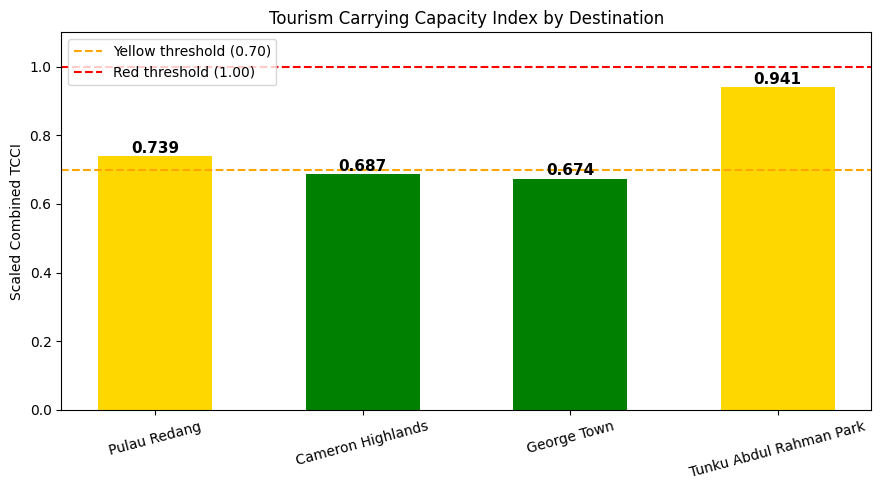

In [7]:
from google.colab import files
uploaded = files.upload()

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ============================================================
# STEP 0: Load coral cover from Null Datathon.xlsx
# ============================================================

FILE = list(uploaded.keys())[0]

raw = pd.read_excel(FILE, sheet_name="Sheet1", header=None)

header_row = None
for i in range(len(raw)):
    if raw.iloc[i].astype(str).str.contains("Destination", na=False).any():
        header_row = i
        break

df_raw = pd.read_excel(FILE, sheet_name="Sheet1", header=header_row)
df_raw.columns = df_raw.columns.astype(str).str.strip()
df_raw["Destination"] = df_raw["Destination"].ffill()

def get_value(dest, metric):
    row = df_raw[
        (df_raw["Destination"] == dest) &
        (df_raw["Metric Name"].astype(str).str.strip() == metric)
    ]
    if row.empty:
        return np.nan
    val = str(row.iloc[0]["Value"]).strip()
    for suffix in [" millions", " million", " thousand", " MLD", " tonnes",
                   " WQI Index (0-100)", " WQI Index (0–100)", " WQI (0-100)", " WQI (0–100)"]:
        val = val.replace(suffix, "")
    val = val.strip()
    try:
        v = float(val)
    except ValueError:
        return np.nan
    s = str(row.iloc[0]["Value"]).lower()
    if "million" in s:
        v = v * 1_000_000
    elif "thousand" in s:
        v = v * 1_000
    return v

# ============================================================
# STEP 1: Build destination data
# ============================================================

destinations = {
    "Pulau Redang": {
        "coral_cover": get_value("Pulau Redang", "Coral cover"),
        "nrw": get_value("Pulau Redang", "Non-Revenue Water (NRW)"),
        "water_mld": get_value("Pulau Redang", "Non-domestic water consumption"),
        "aor": 56.9,
        "yoy_growth": 5.4,
    },
    "Cameron Highlands": {
        "coral_cover": np.nan,
        "nrw": get_value("Cameron Highlands", "Non-Revenue Water (NRW)"),
        "water_mld": get_value("Cameron Highlands", "Non-domestic water consumption"),
        "aor": 54.8,
        "yoy_growth": 6.9,
    },
    "George Town": {
        "coral_cover": np.nan,
        "nrw": get_value("George Town", "Non-Revenue Water (NRW)"),
        "water_mld": get_value("George Town", "Non-domestic water consumption"),
        "aor": 65.3,
        "yoy_growth": 6.4,
    },
    "Tunku Abdul Rahman Park": {
        "coral_cover": get_value("Tunku Abdul Rahman Park", "Coral cover"),
        "nrw": get_value("Tunku Abdul Rahman Park", "Non-Revenue Water (NRW)"),
        "water_mld": get_value("Tunku Abdul Rahman Park", "Non-domestic water consumption"),
        "aor": 57.4,
        "yoy_growth": 5.9,
    },
}

df = pd.DataFrame(destinations).T

# ============================================================
# STEP 2: Normalize Indicators
# ============================================================

# --- I1: NRW (raw value, no normalisation — matching Tourism_1) ---
df["I1_NRW"] = df["nrw"]

# --- I2: Ecological Pressure ---
df["I2_Ecological_Pressure"] = np.nan
df.loc["Pulau Redang", "I2_Ecological_Pressure"] = 1 - df.loc["Pulau Redang", "coral_cover"]
df.loc["Tunku Abdul Rahman Park", "I2_Ecological_Pressure"] = 1 - df.loc["Tunku Abdul Rahman Park", "coral_cover"]
df.loc["Cameron Highlands", "I2_Ecological_Pressure"] = 2 / 5.0
df.loc["George Town", "I2_Ecological_Pressure"] = 1 - (74.125 / 100.0)

# --- I3: Accommodation Pressure ---
aor_min, aor_max = 40, 85
df["I3_Accommodation_Pressure"] = (df["aor"] - aor_min) / (aor_max - aor_min)

# --- I4: Demand Growth Pressure ---
df["I4_Demand_Growth_Pressure"] = df["yoy_growth"] / 15.0

# --- I5: Water Consumption ---
water_min, water_max = 100, 400
df["I5_Water_Consumption"] = (df["water_mld"] - water_min) / (water_max - water_min)

indicator_cols = [
    "I1_NRW",
    "I2_Ecological_Pressure",
    "I3_Accommodation_Pressure",
    "I4_Demand_Growth_Pressure",
    "I5_Water_Consumption",
]

df[indicator_cols] = df[indicator_cols].clip(0, 1)

print("Indicator Matrix:")
print(df[indicator_cols].to_string())

# ============================================================
# STEP 3: AHP Weights
# ============================================================

w_ahp = np.array([0.1452, 0.3704, 0.2078, 0.0958, 0.1809])

# ============================================================
# STEP 4: Entropy Weight Method
# ============================================================

def entropy_weights(data_matrix):
    n, m = data_matrix.shape
    eps = 1e-10
    col_sums = data_matrix.sum(axis=0)
    col_sums[col_sums == 0] = eps
    P = data_matrix / col_sums
    E = np.zeros(m)
    k = 1.0 / np.log(n)
    for j in range(m):
        pj = P[:, j]
        pj = pj[pj > eps]
        E[j] = -k * np.sum(pj * np.log(pj + eps))
    D = 1 - E
    w = D / D.sum()
    return w, E, D

X = df[indicator_cols].values
w_ewm, E_vals, D_vals = entropy_weights(X)

print("\nEWM weights:", w_ewm)

# ============================================================
# STEP 5: Compute CCI
# ============================================================

SCALE_FACTOR = 1.5

df["TCCI_AHP"] = X @ w_ahp
df["TCCI_Entropy"] = X @ w_ewm
df["TCCI_Combined"] = (df["TCCI_AHP"] + df["TCCI_Entropy"]) / 2
df["TCCI_Scaled"] = df["TCCI_Combined"] * SCALE_FACTOR

# ============================================================
# STEP 6: Classification
# ============================================================

def assign_status(idx):
    if idx < 0.70:
        return "Green (Safe)"
    elif idx < 1.00:
        return "Yellow (Warning)"
    else:
        return "Red (Critical)"

df["Status"] = df["TCCI_Scaled"].apply(assign_status)

# ============================================================
# STEP 7: Spearman
# ============================================================

corr, pval = spearmanr(df["TCCI_AHP"], df["TCCI_Entropy"])
print(f"\nSpearman correlation (AHP vs EWM): {corr:.4f} (p = {pval:.4f})")

# ============================================================
# STEP 8: Results
# ============================================================

print("=" * 90)
print("TCCI RESULTS")
print("=" * 90)
print(
    df[
        ["coral_cover", "nrw", "water_mld", "aor", "yoy_growth",
         "TCCI_AHP", "TCCI_Entropy", "TCCI_Combined", "TCCI_Scaled", "Status"]
    ].to_string()
)
print("=" * 90)

# ============================================================
# STEP 9: Plot
# ============================================================

colors = df["Status"].map(
    {"Green (Safe)": "green", "Yellow (Warning)": "gold", "Red (Critical)": "red"}
)

plt.figure(figsize=(9, 5))
bars = plt.bar(df.index, df["TCCI_Scaled"], color=colors, width=0.55)

for bar, val in zip(bars, df["TCCI_Scaled"]):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
             f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")

plt.axhline(y=0.70, color="orange", linestyle="--", label="Yellow threshold (0.70)")
plt.axhline(y=1.00, color="red", linestyle="--", label="Red threshold (1.00)")
plt.ylabel("Scaled Combined TCCI")
plt.title("Tourism Carrying Capacity Index by Destination")
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()